In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from pathlib import Path
import numpy as np
import os

In [2]:
print(os.getcwd())

/Users/trba/Documents/Projects/Serbia_housing/machine_learning


In [3]:
env_path = Path("/Users/trba/Documents/Projects/Serbia_housing/.env.aws")
load_dotenv(env_path)

True

In [4]:
engine = create_engine(f"postgresql+psycopg2://{os.getenv("DB_USER")}:{os.getenv("DB_PASSWORD")}@{os.getenv("DB_HOST")}:{os.getenv("DB_PORT")}/{os.getenv("DB_NAME")}")

In [5]:
df = pd.read_sql("SELECT * FROM gold.unified_deduplicated",engine)

In [6]:
print(f"Broj oglasa: {len(df)}")
print(f"Kolone: {df.columns.tolist()}")

Broj oglasa: 23680
Kolone: ['stan_id', 'oglas_id', 'izvor', 'url', 'title', 'price_total', 'price_avg', 'price_per_m2', 'tip_nekretnine', 'kvadratura', 'broj_soba', 'oglasivac', 'tip_objekta', 'stanje_objekta', 'grejanje', 'sprat', 'ukupna_spratnost', 'uknjizen', 'terasa', 'interfon', 'klima', 'video_nadzor', 'internet', 'parking', 'garaza', 'lift', 'podrum', 'linije_gradskog_prevoza', 'datum_objave', 'dodatni_opis', 'lokacija', 'created_at']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23680 entries, 0 to 23679
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   stan_id                  23680 non-null  str           
 1   oglas_id                 23680 non-null  str           
 2   izvor                    23680 non-null  str           
 3   url                      23680 non-null  str           
 4   title                    23669 non-null  str           
 5   price_total              23680 non-null  float64       
 6   price_avg                23680 non-null  float64       
 7   price_per_m2             23673 non-null  float64       
 8   tip_nekretnine           19994 non-null  str           
 9   kvadratura               23680 non-null  float64       
 10  broj_soba                23680 non-null  float64       
 11  oglasivac                10857 non-null  str           
 12  tip_objekta              6265 non-null   st

In [8]:
df.describe()

,price_total,price_avg,price_per_m2,kvadratura,broj_soba,sprat,ukupna_spratnost,created_at
count,2.368000e+04,2.368000e+04,23673.000000,23680.000000,23680.000000,22231.000000,11538.00000,23680
mean,2.780412e+05,2.780412e+05,17866.123812,78.127184,2.831820,3.229252,5.82770,2026-04-15 14:54:41.422449
min,2.500000e+04,2.500000e+04,0.000000,15.000000,0.500000,-1.000000,1.00000,2026-04-09 14:55:15.522204
25%,1.450000e+05,1.457500e+05,3133.000000,51.000000,2.000000,1.000000,3.00000,2026-04-10 18:24:34.997794
50%,2.190000e+05,2.190000e+05,5269.000000,68.000000,3.000000,2.000000,5.00000,2026-04-11 09:46:41.947112
75%,3.330000e+05,3.336362e+05,32032.000000,94.000000,3.500000,4.000000,7.00000,2026-04-16 17:20:26.779426
max,2.000000e+06,2.000000e+06,200002.000000,400.000000,20.000000,37.000000,42.00000,2026-05-04 07:30:24.232728
std,2.171039e+05,2.170170e+05,18353.936872,41.575113,1.120952,3.397280,4.71064,NaN


In [9]:
null_values = (df.isnull().sum() / len(df) * 100).sort_values(ascending = False)
print(null_values.round(1))

video_nadzor               84.1
podrum                     79.6
garaza                     75.5
tip_objekta                73.5
linije_gradskog_prevoza    72.2
parking                    59.9
internet                   55.3
oglasivac                  54.2
ukupna_spratnost           51.3
klima                      48.4
uknjizen                   46.1
lift                       43.6
interfon                   34.6
stanje_objekta             25.6
terasa                     23.7
tip_nekretnine             15.6
datum_objave               13.4
grejanje                    7.0
sprat                       6.1
lokacija                    1.9
dodatni_opis                0.1
title                       0.0
price_per_m2                0.0
stan_id                     0.0
oglas_id                    0.0
broj_soba                   0.0
kvadratura                  0.0
price_avg                   0.0
price_total                 0.0
url                         0.0
izvor                       0.0
created_

In [10]:
df["price_per_m2_cal"] = df["price_total"] / df["kvadratura"]


In [11]:
print(f"Originalna cena: {df["price_per_m2"]}")
print(f"Izracunata cena cena: {df["price_per_m2_cal"]}")

Originalna cena: 0        38522.0
1        42902.0
2        63292.0
3        32042.0
4        18702.0
          ...   
23675     2527.0
23676     2553.0
23677     2748.0
23678     4000.0
23679     2782.0
Name: price_per_m2, Length: 23680, dtype: float64
Izracunata cena cena: 0        3852.459016
1        4518.766258
2        5365.732039
3        3393.203883
4        2024.147727
            ...     
23675    2527.027027
23676    2553.191489
23677    2747.747748
23678    4000.000000
23679    2782.258065
Name: price_per_m2_cal, Length: 23680, dtype: float64


In [12]:
df["razlika"] = df["price_per_m2"] - df["price_per_m2_cal"]
df["razlika_abs"] = df["razlika"].abs()

In [13]:
print(f"Razlika u ceni: {df["razlika"].round(2)}")
print(f"Razlika u ceni abs: {df["razlika_abs"].round(2)}")

Razlika u ceni: 0        34669.54
1        38383.23
2        57926.27
3        28648.80
4        16677.85
           ...   
23675       -0.03
23676       -0.19
23677        0.25
23678       -0.00
23679       -0.26
Name: razlika, Length: 23680, dtype: float64
Razlika u ceni abs: 0        34669.54
1        38383.23
2        57926.27
3        28648.80
4        16677.85
           ...   
23675        0.03
23676        0.19
23677        0.25
23678        0.00
23679        0.26
Name: razlika_abs, Length: 23680, dtype: float64


In [14]:
###### STATISTIKA ####
print(f"Cena se razlikuje za manje od 1%:   {(df["razlika_abs"] < 0.01).sum()} / {len(df)}")
print(f"Cena se razlikuje za ili vise od 1%:   {(df["razlika_abs"] >= 0.01).sum()}")
print(f"MAKS razlika u ceni:   {df["razlika_abs"].max():.2f} EUR/m2")
print(f"SREDNJA razlika u ceni:   {df["razlika_abs"].mean():.2f} EUR/m2")

Cena se razlikuje za manje od 1%:   2871 / 23680
Cena se razlikuje za ili vise od 1%:   20802
MAKS razlika u ceni:   186775.61 EUR/m2
SREDNJA razlika u ceni:   14551.97 EUR/m2


In [15]:
outlieri = df[df["razlika_abs"] >= 1].sort_values("razlika_abs", ascending=False)
print(f"\n=== Top 10 neslaganja ===")
print(outlieri[["oglas_id", "price_total", "kvadratura", 
                "price_per_m2", "price_per_m2_cal", "razlika"]].head(10).to_string())


=== Top 10 neslaganja ===
                       oglas_id  price_total  kvadratura  price_per_m2  price_per_m2_cal        razlika
220               5425646979175     145000.0      147.00      187762.0        986.394558  186775.605442
6257              5425646947866    1470000.0       73.00      200002.0      20136.986301  179865.013699
222               5425646979174    1500000.0       74.00      198652.0      20270.270270  178381.729730
2372              5425646449478     590000.0       61.04      119922.0       9665.792923  110256.207077
7423              5425646931127    1000000.0       88.00      113642.0      11363.636364  102278.363636
2793              5425646866602    1498000.0      164.00      109762.0       9134.146341  100627.853659
9765              5425646184757    1400000.0      136.26      110082.0      10274.475268   99807.524732
6327              5425646699568    1800000.0      163.50      110092.0      11009.174312   99082.825688
10243  69aed559db648a7ab10930b3    18

In [16]:
mask = df["sprat"].notna() & df["ukupna_spratnost"].notna() & (df["ukupna_spratnost"] != 0)

In [17]:
df.loc[mask,"sprat_ratio"] = df.loc[mask,"sprat"] / df.loc[mask,"ukupna_spratnost"]
print(df["sprat_ratio"].value_counts(dropna=False))

sprat_ratio
NaN         12449
1.000000     2562
0.500000     1073
0.000000      909
0.333333      734
            ...  
1.400000        1
4.000000        1
1.250000        1
0.521739        1
0.937500        1
Name: count, Length: 202, dtype: int64


In [18]:
df["sprat_ratio"] = df.loc[mask, "sprat"] / df.loc[mask, "ukupna_spratnost"]
print(df["sprat_ratio"].value_counts(dropna=False))

sprat_ratio
NaN         12449
1.000000     2562
0.500000     1073
0.000000      909
0.333333      734
            ...  
1.400000        1
4.000000        1
1.250000        1
0.521739        1
0.937500        1
Name: count, Length: 202, dtype: int64


In [19]:
outlier = df[df["sprat_ratio"] > 1]["url"]
pd.set_option("display.max_colwidth", None)
print(outlier.to_string())

181                                                           https://www.nekretnine.rs/stambeni-objekti/stanovi/na-prodaju-dvosoban-stan---altina-centar/Nkji8Ubn0Va/
208                                                        https://www.nekretnine.rs/stambeni-objekti/stanovi/noviji-jedinstveni-lux-penthaus-103-m2-92m2/Nkz-sgA-4QQ/
3049                                                                   https://www.nekretnine.rs/stambeni-objekti/stanovi/dvosoban-stan-mirijevo-zvezdara/NkJWFGBeULU/
5118                                                      https://www.nekretnine.rs/stambeni-objekti/stanovi/trosoban-stan-kod-hrama-stojana-protica-85m2/NkCsKxDuEKW/
6948                                                             https://www.nekretnine.rs/stambeni-objekti/stanovi/vracar-kalenic-sindeliceva-51m2-25-44/NkVRftCMCtU/
9283                                                                    https://www.nekretnine.rs/stambeni-objekti/stanovi/mirijevo-novogradnja--dvosoban/NkIFYX0vaAs

In [20]:
mask_valid = df["sprat_ratio"].between(0,1)
df = df[mask_valid].copy()
print(f"Izbačeno: {(~mask_valid).sum()} oglasa od {len(df)}")

Izbačeno: 12517 oglasa od 11163


In [21]:
print(df["sprat_ratio"].isna().sum())
print(df["sprat_ratio"].between(0, 1).sum())
print((df["sprat_ratio"] > 1).sum())

0
11163
0


In [22]:
bool_cols =["uknjizen", "terasa", "interfon", "klima", 
             "video_nadzor", "internet", "parking", "garaza", "lift", "podrum"]

In [23]:
df["amenity_score"] = df[bool_cols].sum(axis = 1)

In [24]:
print(df["amenity_score"].value_counts().sort_index())

amenity_score
0       68
1      452
2      997
3     1657
4     2026
5     2143
6     1698
7     1113
8      683
9      288
10      38
Name: count, dtype: int64


In [25]:
print(df["stanje_objekta"].value_counts(dropna = False))

stanje_objekta
NaN                         5346
Lux                         2109
Renovirano                  1069
Izvorno_stanje               994
Uobičajeno stanje            672
Novogradnja                  360
Standardna gradnja           249
Za renoviranje               133
U izgradnji                  113
Kompletna rekonstrukcija      88
Delimična rekonstrukcija      14
Završena izgradnja            12
U pripremi                     4
Name: count, dtype: int64


In [26]:
print(df["lokacija"].value_counts().head(20))

lokacija
Nepoznato         4789
Vracar             805
Centar             532
Novi Beograd       404
Zemun              335
Zvezdara           299
Vozdovac           231
Mirijevo           215
Karaburma          174
Dorcol             165
Stari Grad         151
Banovo Brdo        137
Savski Venac       131
Vidikovac          126
Brace Jerkovic     123
Kalemegdan         111
Ledine              98
Dedinje             97
Crveni Krst         97
Surcin              93
Name: count, dtype: int64


In [27]:
print(df["lokacija"].nunique())

122


In [28]:
print(df[df["lokacija"].isna()][["url","lokacija"]])

                                                                                                                    url  \
387             https://www.halooglasi.com/nekretnine/prodaja-stanova/bw-iris-80m2-3-0-2-garaze-lux/5425646769951?kid=4   
996      https://www.halooglasi.com/nekretnine/prodaja-stanova/bw-perla-lux-3-0-bazen-garaza-id3230/5425647043610?kid=4   
1249       https://www.halooglasi.com/nekretnine/prodaja-stanova/nov-lux-uknjizen-sa-parking-mestom/5425647044219?kid=4   
10130              https://www.4zida.rs/prodaja-stanova/kalenic-vracar-beograd/jednosoban-stan/69e2c09e45e871d9de099b2b   
10131   https://www.4zida.rs/prodaja-stanova/surcin-mesto-surcin-opstina-beograd/dvosoban-stan/69e29553f17dfa8911092ad2   
...                                                                                                                 ...   
17352   https://www.nekretnine.rs/stambeni-objekti/stanovi/lux-novogradnja-smart-stanovi---moguc-na-kredit/Nk36MdD5DC5/   
17395     https:

In [29]:
print(df["datum_objave"].dtype)
print(df["datum_objave"].value_counts().sort_index().tail(10))

object
datum_objave
2026-04-24    123
2026-04-25     56
2026-04-26     58
2026-04-27     90
2026-04-28     91
2026-04-29     89
2026-04-30     86
2026-05-01     16
2026-05-02     15
2026-05-03     11
Name: count, dtype: int64


In [30]:
df['lokacija'] = df['lokacija'].replace('Nepoznato', None)

In [31]:
print(df['lokacija'].value_counts())

lokacija
Vracar            805
Centar            532
Novi Beograd      404
Zemun             335
Zvezdara          299
                 ... 
Trg republike       1
A blok              1
Terazije            1
Obilicev Venac      1
Kumodraz            1
Name: count, Length: 121, dtype: int64


In [32]:
from datetime import date
df["starost_oglasa"] = (pd.to_datetime(date.today()) - pd.to_datetime(df["datum_objave"])).dt.days
print(df['starost_oglasa'])

0         31.0
1         31.0
2         31.0
3         31.0
4         31.0
         ...  
23526      7.0
23541      7.0
23559      7.0
23624    278.0
23656    144.0
Name: starost_oglasa, Length: 11163, dtype: float64


In [33]:
print(df.nsmallest(5, "starost_oglasa")[["url", "datum_objave", "starost_oglasa"]])

                                                                                                                           url  \
3605         https://www.halooglasi.com/nekretnine/prodaja-stanova/top-lokacijadobracina-centar-1-5-stan-useljiv/5425647103150   
3708   https://www.halooglasi.com/nekretnine/prodaja-stanova/trosoban-stan-kvalitetna-novogradnja-u-izgrad/5425647072938?kid=4   
13397           https://www.4zida.rs/prodaja-stanova/kaludjerica-grocka-opstina-beograd/trosoban-stan/69f6b5a1f48c9ffa3a0fb4d3   
13418                 https://www.4zida.rs/prodaja-stanova/blok-65-novi-beograd-beograd/trosoban-stan/69f7abe63f559b0b8f03bbf6   
13419     https://www.4zida.rs/prodaja-stanova/visnjicka-banja-palilula-opstina-beograd/dvosoban-stan/69f7837570b21b244400af6a   

      datum_objave  starost_oglasa  
3605    2026-05-03             7.0  
3708    2026-05-03             7.0  
13397   2026-05-03             7.0  
13418   2026-05-03             7.0  
13419   2026-05-03             7.0

In [34]:
from sklearn.model_selection import train_test_split

In [37]:
df["datum_objave"] = pd.to_datetime(df["datum_objave"])
df = df[df["datum_objave"] >= "2024-01-01"].copy()
print(f"Oglasa: {len(df)}")

Oglasa: 8332


In [39]:
def mesec_u_kvartal(period):
    year = period.year
    quarter = period.quarter
    return f"{year}-Q{quarter}"

df["kvartal"] = df["datum_objave"].dt.to_period("M").apply(mesec_u_kvartal)
print(df["kvartal"].value_counts().sort_index())

kvartal
2024-Q1       9
2024-Q2       4
2024-Q3      21
2024-Q4      34
2025-Q1      61
2025-Q2     119
2025-Q3     170
2025-Q4     228
2026-Q1    2934
2026-Q2    4752
Name: count, dtype: int64


In [42]:
train_val, test = train_test_split(df, test_size=0.2, random_state=42,
                                   stratify=df["kvartal"])

train, val = train_test_split(train_val, test_size=0.125, random_state=42,
                              stratify=train_val["kvartal"])

print(f"Train: {len(train)}")
print(f"Val:   {len(val)}")
print(f"Test:  {len(test)}")

Train: 5831
Val:   834
Test:  1667


In [43]:
import category_encoders as ce

encoder = ce.TargetEncoder(cols=["lokacija"])
train["lokacija_encoded"] = encoder.fit_transform(train["lokacija"], train["price_total"])
val["lokacija_encoded"]   = encoder.transform(val["lokacija"])
test["lokacija_encoded"]  = encoder.transform(test["lokacija"])

In [65]:
feature_cols = [
    # Numerički
    "kvadratura", "broj_soba", "sprat", "ukupna_spratnost",
     "sprat_ratio", "amenity_score", "starost_oglasa",
    # Kategorički
    "lokacija_encoded", "stanje_objekta", "grejanje", "oglasivac", "tip_nekretnine",
    # Boolean
    "terasa", "parking", "garaza", "lift", "podrum",
    "internet", "klima", "interfon", "video_nadzor", "uknjizen"
]

In [66]:
X_train = train[feature_cols]
Y_train = train['price_total']

In [67]:
print(train.columns.tolist())

['stan_id', 'oglas_id', 'izvor', 'url', 'title', 'price_total', 'price_avg', 'price_per_m2', 'tip_nekretnine', 'kvadratura', 'broj_soba', 'oglasivac', 'tip_objekta', 'stanje_objekta', 'grejanje', 'sprat', 'ukupna_spratnost', 'uknjizen', 'terasa', 'interfon', 'klima', 'video_nadzor', 'internet', 'parking', 'garaza', 'lift', 'podrum', 'linije_gradskog_prevoza', 'datum_objave', 'dodatni_opis', 'lokacija', 'created_at', 'price_per_m2_cal', 'razlika', 'razlika_abs', 'sprat_ratio', 'amenity_score', 'starost_oglasa', 'kvartal', 'lokacija_encoded']


In [68]:
X_val = val[feature_cols]
Y_val = val['price_total']

In [69]:
X_test = test[feature_cols]
y_test = test['price_total']

In [70]:
print(X_train.shape)

(5831, 22)


In [71]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [72]:
model = lgb.LGBMRegressor(random_state = 42,n_jobs = 1)

In [73]:
# String kolone - category
cat_cols = ["stanje_objekta", "grejanje", "oglasivac", "tip_nekretnine"]
for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col]   = X_val[col].astype("category")
    X_test[col]  = X_test[col].astype("category")

# Boolean kolone - float (NaN ostaje NaN)
bool_cols = ["terasa", "parking", "garaza", "lift", "podrum",
             "internet", "klima", "interfon", "video_nadzor", "uknjizen"]
for col in bool_cols:
    X_train[col] = X_train[col].astype(float)
    X_val[col]   = X_val[col].astype(float)
    X_test[col]  = X_test[col].astype(float)

# amenity_score - float
X_train["amenity_score"] = X_train["amenity_score"].astype(float)
X_val["amenity_score"]   = X_val["amenity_score"].astype(float)
X_test["amenity_score"]  = X_test["amenity_score"].astype(float)

In [74]:
model.fit(X_train,Y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [75]:
y_pred_val = model.predict(X_val)

print(f"MAE:  {mean_absolute_error(Y_val, y_pred_val):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(Y_val, y_pred_val):,.0f} EUR")
print(f"R²:   {r2_score(Y_val, y_pred_val):.3f}")

MAE:  54,300 EUR
RMSE: 92,243 EUR
R²:   0.784


In [77]:
import shap

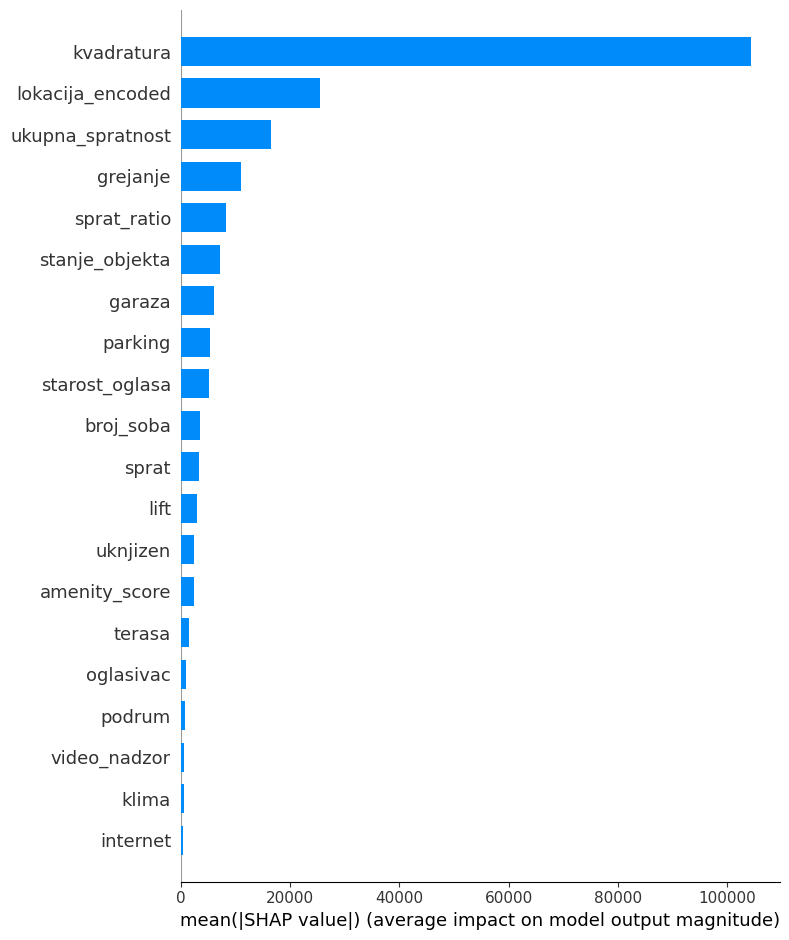

In [78]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values,X_val,plot_type = 'bar')

In [79]:
import optuna

In [84]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators',100,1000),
        'max_depth': trial.suggest_int('max_depth',3,7),
        'num_leaves': trial.suggest_int('num_leaves',20,200),
        'learning_rate': trial.suggest_float('learning_rate',0.01,0.3,log = True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":       trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state": 42,
        "n_jobs": 1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train,Y_train)
    y_pred = model.predict(X_val)
    return mean_absolute_error(Y_val,y_pred)

In [85]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective,n_trials = 50)

[I 2026-05-10 15:39:41,828] A new study created in memory with name: no-name-95f022ed-ab93-40d0-9cb5-4739db72f50a
[I 2026-05-10 15:39:41,904] Trial 0 finished with value: 56593.167770331536 and parameters: {'n_estimators': 263, 'max_depth': 3, 'num_leaves': 127, 'learning_rate': 0.24355618727708972, 'min_child_samples': 80, 'subsample': 0.9263540750858743, 'colsample_bytree': 0.5048603563902667}. Best is trial 0 with value: 56593.167770331536.
[I 2026-05-10 15:39:42,002] Trial 1 finished with value: 58611.46179127504 and parameters: {'n_estimators': 408, 'max_depth': 3, 'num_leaves': 118, 'learning_rate': 0.01501622246766513, 'min_child_samples': 52, 'subsample': 0.6003484944277397, 'colsample_bytree': 0.7433958087117362}. Best is trial 0 with value: 56593.167770331536.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:42,279] Trial 2 finished with value: 54685.67676760442 and parameters: {'n_estimators': 671, 'max_depth': 7, 'num_leaves': 119, 'learning_rate': 0.08566656381745508, 'min_child_samples': 95, 'subsample': 0.7757720879941931, 'colsample_bytree': 0.6340657657659894}. Best is trial 2 with value: 54685.67676760442.
[I 2026-05-10 15:39:42,388] Trial 3 finished with value: 52649.60213532027 and parameters: {'n_estimators': 247, 'max_depth': 7, 'num_leaves': 58, 'learning_rate': 0.12251447434133014, 'min_child_samples': 35, 'subsample': 0.8874508065442257, 'colsample_bytree': 0.8726922432895157}. Best is trial 3 with value: 52649.60213532027.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000472 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:42,598] Trial 4 finished with value: 55800.93585528998 and parameters: {'n_estimators': 682, 'max_depth': 5, 'num_leaves': 145, 'learning_rate': 0.024401189155785513, 'min_child_samples': 83, 'subsample': 0.6403646013031059, 'colsample_bytree': 0.9098105468723918}. Best is trial 3 with value: 52649.60213532027.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:42,756] Trial 5 finished with value: 55135.52880401525 and parameters: {'n_estimators': 677, 'max_depth': 3, 'num_leaves': 139, 'learning_rate': 0.17386137228991555, 'min_child_samples': 30, 'subsample': 0.865872830113195, 'colsample_bytree': 0.5302547699105049}. Best is trial 3 with value: 52649.60213532027.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:43,035] Trial 6 finished with value: 56115.71577343298 and parameters: {'n_estimators': 751, 'max_depth': 6, 'num_leaves': 60, 'learning_rate': 0.20138568386612893, 'min_child_samples': 75, 'subsample': 0.8062316655881474, 'colsample_bytree': 0.7225074124252939}. Best is trial 3 with value: 52649.60213532027.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:43,368] Trial 7 finished with value: 54797.73672052652 and parameters: {'n_estimators': 814, 'max_depth': 5, 'num_leaves': 141, 'learning_rate': 0.21521941626968724, 'min_child_samples': 11, 'subsample': 0.9418089797583735, 'colsample_bytree': 0.822140711119594}. Best is trial 3 with value: 52649.60213532027.
[I 2026-05-10 15:39:43,412] Trial 8 finished with value: 56606.590990544784 and parameters: {'n_estimators': 132, 'max_depth': 3, 'num_leaves': 116, 'learning_rate': 0.0960545998019042, 'min_child_samples': 32, 'subsample': 0.7039722489480764, 'colsample_bytree': 0.6112004996095404}. Best is trial 3 with value: 52649.60213532027.
[I 2026-05-10 15:39:43,483] Trial 9 finished with value: 57411.40873518554 and parameters: {'n_estimators': 143, 'max_depth': 6, 'num_leaves': 145, 'learning_rate': 0.03231748514317396, 'min_child_samples': 97, 'subsample': 0.5758238891656907, 'colsample_bytree': 0.787602490567318}. Best is trial 3 with value: 52649.60213532027.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000400 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:43,682] Trial 10 finished with value: 54100.48522784284 and parameters: {'n_estimators': 448, 'max_depth': 7, 'num_leaves': 200, 'learning_rate': 0.05742154109462344, 'min_child_samples': 45, 'subsample': 0.9744351436721445, 'colsample_bytree': 0.998841026309598}. Best is trial 3 with value: 52649.60213532027.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:43,867] Trial 11 finished with value: 53822.1543522939 and parameters: {'n_estimators': 416, 'max_depth': 7, 'num_leaves': 197, 'learning_rate': 0.056368938254906104, 'min_child_samples': 49, 'subsample': 0.9962995711763887, 'colsample_bytree': 0.9967551272220494}. Best is trial 3 with value: 52649.60213532027.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:43,992] Trial 12 finished with value: 54325.933408498146 and parameters: {'n_estimators': 351, 'max_depth': 6, 'num_leaves': 36, 'learning_rate': 0.10264620026868411, 'min_child_samples': 64, 'subsample': 0.9958069231268698, 'colsample_bytree': 0.9950918007678135}. Best is trial 3 with value: 52649.60213532027.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000497 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:44,388] Trial 13 finished with value: 52208.26321535456 and parameters: {'n_estimators': 960, 'max_depth': 7, 'num_leaves': 77, 'learning_rate': 0.043958046676396016, 'min_child_samples': 37, 'subsample': 0.87127633486086, 'colsample_bytree': 0.898604381051504}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:44,739] Trial 14 finished with value: 53892.68219948026 and parameters: {'n_estimators': 982, 'max_depth': 6, 'num_leaves': 72, 'learning_rate': 0.03449555195881514, 'min_child_samples': 30, 'subsample': 0.8664679406047351, 'colsample_bytree': 0.8814362754485523}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:45,025] Trial 15 finished with value: 54855.309639814586 and parameters: {'n_estimators': 917, 'max_depth': 4, 'num_leaves': 80, 'learning_rate': 0.011278696755056258, 'min_child_samples': 14, 'subsample': 0.5051268184494105, 'colsample_bytree': 0.88774935290514}. Best is trial 13 with value: 52208.26321535456.
[I 2026-05-10 15:39:45,234] Trial 16 finished with value: 53241.196240012156 and parameters: {'n_estimators': 539, 'max_depth': 7, 'num_leaves': 28, 'learning_rate': 0.1370182486242558, 'min_child_samples': 39, 'subsample': 0.8714039981383284, 'colsample_bytree': 0.8355433285844651}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000445 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:45,362] Trial 17 finished with value: 55580.58607326141 and parameters: {'n_estimators': 259, 'max_depth': 7, 'num_leaves': 90, 'learning_rate': 0.042638215340739076, 'min_child_samples': 67, 'subsample': 0.8255842965272855, 'colsample_bytree': 0.9251911733183213}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000495 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:45,648] Trial 18 finished with value: 54277.73195155403 and parameters: {'n_estimators': 862, 'max_depth': 5, 'num_leaves': 51, 'learning_rate': 0.021515440027940372, 'min_child_samples': 27, 'subsample': 0.7252052173762535, 'colsample_bytree': 0.6813625974880461}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:45,897] Trial 19 finished with value: 52805.55103137361 and parameters: {'n_estimators': 566, 'max_depth': 6, 'num_leaves': 97, 'learning_rate': 0.0695607820597459, 'min_child_samples': 19, 'subsample': 0.9109034206040678, 'colsample_bytree': 0.8371288350929277}. Best is trial 13 with value: 52208.26321535456.
[I 2026-05-10 15:39:46,038] Trial 20 finished with value: 54598.72447758438 and parameters: {'n_estimators': 529, 'max_depth': 4, 'num_leaves': 47, 'learning_rate': 0.16086939198086392, 'min_child_samples': 41, 'subsample': 0.7671469682264964, 'colsample_bytree': 0.9373311513185947}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:46,298] Trial 21 finished with value: 52747.76242092109 and parameters: {'n_estimators': 600, 'max_depth': 6, 'num_leaves': 92, 'learning_rate': 0.06815375540519739, 'min_child_samples': 18, 'subsample': 0.9123004985648933, 'colsample_bytree': 0.8331899770233726}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:46,418] Trial 22 finished with value: 53521.17001613825 and parameters: {'n_estimators': 233, 'max_depth': 7, 'num_leaves': 71, 'learning_rate': 0.11956302678258027, 'min_child_samples': 20, 'subsample': 0.8910335865700604, 'colsample_bytree': 0.8012298153535206}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:46,765] Trial 23 finished with value: 53024.43719910654 and parameters: {'n_estimators': 995, 'max_depth': 6, 'num_leaves': 99, 'learning_rate': 0.07083966031987661, 'min_child_samples': 37, 'subsample': 0.8226596259591618, 'colsample_bytree': 0.870070057319885}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:47,068] Trial 24 finished with value: 58639.15536246499 and parameters: {'n_estimators': 776, 'max_depth': 7, 'num_leaves': 21, 'learning_rate': 0.2975614624223223, 'min_child_samples': 22, 'subsample': 0.9557551351981136, 'colsample_bytree': 0.7712450173946841}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:47,278] Trial 25 finished with value: 55094.22900437367 and parameters: {'n_estimators': 592, 'max_depth': 6, 'num_leaves': 61, 'learning_rate': 0.0440130156047125, 'min_child_samples': 58, 'subsample': 0.8443191690426914, 'colsample_bytree': 0.8571268615567891}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:47,437] Trial 26 finished with value: 53256.32069424227 and parameters: {'n_estimators': 340, 'max_depth': 7, 'num_leaves': 170, 'learning_rate': 0.07306174990007151, 'min_child_samples': 24, 'subsample': 0.9066752343942557, 'colsample_bytree': 0.9145431267145305}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:47,608] Trial 27 finished with value: 53641.630372155414 and parameters: {'n_estimators': 487, 'max_depth': 5, 'num_leaves': 82, 'learning_rate': 0.045599190181654606, 'min_child_samples': 34, 'subsample': 0.7970657815185564, 'colsample_bytree': 0.9524413605714155}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:47,893] Trial 28 finished with value: 52605.6453710187 and parameters: {'n_estimators': 628, 'max_depth': 6, 'num_leaves': 98, 'learning_rate': 0.12162267842951212, 'min_child_samples': 15, 'subsample': 0.6933874094970623, 'colsample_bytree': 0.7084241977778508}. Best is trial 13 with value: 52208.26321535456.
[I 2026-05-10 15:39:47,993] Trial 29 finished with value: 53998.67972247867 and parameters: {'n_estimators': 206, 'max_depth': 7, 'num_leaves': 106, 'learning_rate': 0.1348726438196362, 'min_child_samples': 47, 'subsample': 0.678902740721436, 'colsample_bytree': 0.7156881427216227}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:48,138] Trial 30 finished with value: 56510.15964682327 and parameters: {'n_estimators': 328, 'max_depth': 7, 'num_leaves': 49, 'learning_rate': 0.262368084800415, 'min_child_samples': 57, 'subsample': 0.7441449157124375, 'colsample_bytree': 0.6719257110011607}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000437 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:48,426] Trial 31 finished with value: 53318.550827842635 and parameters: {'n_estimators': 623, 'max_depth': 6, 'num_leaves': 86, 'learning_rate': 0.11122513232233887, 'min_child_samples': 15, 'subsample': 0.9267066941313739, 'colsample_bytree': 0.7618388021809094}. Best is trial 13 with value: 52208.26321535456.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000450 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:48,768] Trial 32 finished with value: 52168.081508886135 and parameters: {'n_estimators': 719, 'max_depth': 6, 'num_leaves': 70, 'learning_rate': 0.08396675555764972, 'min_child_samples': 11, 'subsample': 0.6608431161440731, 'colsample_bytree': 0.8119460335800833}. Best is trial 32 with value: 52168.081508886135.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:49,109] Trial 33 finished with value: 55652.563331318466 and parameters: {'n_estimators': 873, 'max_depth': 5, 'num_leaves': 69, 'learning_rate': 0.15597279402554168, 'min_child_samples': 10, 'subsample': 0.6681201881540088, 'colsample_bytree': 0.7342854571771594}. Best is trial 32 with value: 52168.081508886135.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:49,458] Trial 34 finished with value: 52094.107142075656 and parameters: {'n_estimators': 716, 'max_depth': 7, 'num_leaves': 128, 'learning_rate': 0.09140109172284143, 'min_child_samples': 24, 'subsample': 0.617476147249467, 'colsample_bytree': 0.9587834651745565}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:49,764] Trial 35 finished with value: 52881.430237868786 and parameters: {'n_estimators': 725, 'max_depth': 6, 'num_leaves': 123, 'learning_rate': 0.10101166848576001, 'min_child_samples': 24, 'subsample': 0.5852787241454371, 'colsample_bytree': 0.9615645298211346}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:50,121] Trial 36 finished with value: 52213.52697145002 and parameters: {'n_estimators': 648, 'max_depth': 7, 'num_leaves': 130, 'learning_rate': 0.08393286055881027, 'min_child_samples': 15, 'subsample': 0.6170798110898628, 'colsample_bytree': 0.6855892359796169}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:50,450] Trial 37 finished with value: 53401.99685077088 and parameters: {'n_estimators': 695, 'max_depth': 7, 'num_leaves': 158, 'learning_rate': 0.08403522705812437, 'min_child_samples': 27, 'subsample': 0.6228633309842693, 'colsample_bytree': 0.5177392179892786}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:50,925] Trial 38 finished with value: 52780.735934309894 and parameters: {'n_estimators': 790, 'max_depth': 7, 'num_leaves': 110, 'learning_rate': 0.08562179777509582, 'min_child_samples': 11, 'subsample': 0.5371053044598763, 'colsample_bytree': 0.5971900933483988}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000420 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:51,302] Trial 39 finished with value: 53644.18818209307 and parameters: {'n_estimators': 839, 'max_depth': 7, 'num_leaves': 132, 'learning_rate': 0.026538987444755836, 'min_child_samples': 42, 'subsample': 0.6473150529306816, 'colsample_bytree': 0.6512743303359432}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:51,617] Trial 40 finished with value: 54671.67607353272 and parameters: {'n_estimators': 728, 'max_depth': 7, 'num_leaves': 170, 'learning_rate': 0.05786179839464976, 'min_child_samples': 85, 'subsample': 0.6189686936663665, 'colsample_bytree': 0.57788100903591}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:51,902] Trial 41 finished with value: 52870.05821520167 and parameters: {'n_estimators': 649, 'max_depth': 6, 'num_leaves': 129, 'learning_rate': 0.08479108322449036, 'min_child_samples': 16, 'subsample': 0.693890276589177, 'colsample_bytree': 0.7129263330781765}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:52,163] Trial 42 finished with value: 53532.762140430146 and parameters: {'n_estimators': 942, 'max_depth': 4, 'num_leaves': 104, 'learning_rate': 0.04959382352295433, 'min_child_samples': 15, 'subsample': 0.5538711162464234, 'colsample_bytree': 0.6875335448739792}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:52,434] Trial 43 finished with value: 53382.88938579099 and parameters: {'n_estimators': 661, 'max_depth': 6, 'num_leaves': 117, 'learning_rate': 0.03747804577490649, 'min_child_samples': 25, 'subsample': 0.64517833111441, 'colsample_bytree': 0.9641705046227326}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:52,830] Trial 44 finished with value: 55200.16192313 and parameters: {'n_estimators': 724, 'max_depth': 7, 'num_leaves': 148, 'learning_rate': 0.19819211794306804, 'min_child_samples': 21, 'subsample': 0.7201209623280462, 'colsample_bytree': 0.8006897660050062}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:52,981] Trial 45 finished with value: 53769.62180636818 and parameters: {'n_estimators': 487, 'max_depth': 5, 'num_leaves': 78, 'learning_rate': 0.13410810117062663, 'min_child_samples': 31, 'subsample': 0.6024595093264641, 'colsample_bytree': 0.8987489160192288}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:53,437] Trial 46 finished with value: 52747.435786921174 and parameters: {'n_estimators': 770, 'max_depth': 7, 'num_leaves': 123, 'learning_rate': 0.10404103387393498, 'min_child_samples': 11, 'subsample': 0.6660637230273025, 'colsample_bytree': 0.6338390359775655}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 15:39:53,718] Trial 47 finished with value: 53378.58464751255 and parameters: {'n_estimators': 639, 'max_depth': 6, 'num_leaves': 136, 'learning_rate': 0.061206788588850994, 'min_child_samples': 17, 'subsample': 0.621715372609984, 'colsample_bytree': 0.7398090133967344}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:53,949] Trial 48 finished with value: 52755.202078165945 and parameters: {'n_estimators': 693, 'max_depth': 6, 'num_leaves': 116, 'learning_rate': 0.08002409160985037, 'min_child_samples': 30, 'subsample': 0.5645999672939601, 'colsample_bytree': 0.7739923728248361}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000509 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 15:39:54,338] Trial 49 finished with value: 53568.56150506778 and parameters: {'n_estimators': 916, 'max_depth': 7, 'num_leaves': 155, 'learning_rate': 0.029740013148755542, 'min_child_samples': 51, 'subsample': 0.5946280599637755, 'colsample_bytree': 0.9773133534835456}. Best is trial 34 with value: 52094.107142075656.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [86]:
print(f"Najbolje MAE: {study.best_value: ,.0f}EUR")
print(f"Najbolj parametri: {study.best_params}")

Najbolje MAE:  52,094EUR
Najbolj parametri: {'n_estimators': 716, 'max_depth': 7, 'num_leaves': 128, 'learning_rate': 0.09140109172284143, 'min_child_samples': 24, 'subsample': 0.617476147249467, 'colsample_bytree': 0.9587834651745565}


In [88]:
best_model = lgb.LGBMRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=1
)
best_model.fit(X_train, Y_train)

y_pred_test = best_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 5831, number of used features: 22
[LightGBM] [Info] Start training from score 276439.467673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [89]:
print("=== TEST SET ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_test):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_test):,.0f} EUR")
print(f"R²:   {r2_score(y_test, y_pred_test):.3f}")

=== TEST SET ===
MAE:  55,652 EUR
RMSE: 102,243 EUR
R²:   0.794


In [110]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from catboost import CatBoostRegressor

In [114]:
for col in cat_cols:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_val[col]   = X_val[col].fillna("Unknown").astype(str)
    X_test[col]  = X_test[col].fillna("Unknown").astype(str)

cat_model = CatBoostRegressor(random_state=42, verbose=0, cat_features=cat_cols)
cat_model.fit(X_train, Y_train)
y_pred_cat = cat_model.predict(X_val)

print("=== CATBOOST ===")
print(f"MAE:  {mean_absolute_error(Y_val, y_pred_cat):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(Y_val, y_pred_cat):,.0f} EUR")
print(f"R²:   {r2_score(Y_val, y_pred_cat):.3f}")

=== CATBOOST ===
MAE:  52,419 EUR
RMSE: 88,033 EUR
R²:   0.803


In [115]:
y_pred_cat_test = cat_model.predict(X_test)

print("=== CATBOOST TEST SET ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_cat_test):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_cat_test):,.0f} EUR")
print(f"R²:   {r2_score(y_test, y_pred_cat_test):.3f}")

=== CATBOOST TEST SET ===
MAE:  54,745 EUR
RMSE: 101,470 EUR
R²:   0.798


In [117]:
from sklearn.preprocessing import LabelEncoder

X_train_rf = X_train.copy()
X_val_rf = X_val.copy()
X_test_rf = X_test.copy()

le = LabelEncoder()
for col in cat_cols:
    X_train_rf[col] = le.fit_transform(X_train_rf[col].astype(str))
    X_val_rf[col]   = le.transform(X_val_rf[col].astype(str))
    X_test_rf[col]  = le.transform(X_test_rf[col].astype(str))

rf_model = RandomForestRegressor(random_state=42, n_jobs=1)
rf_model.fit(X_train_rf, Y_train)
y_pred_rf = rf_model.predict(X_val_rf)

print("=== RANDOM FOREST ===")
print(f"MAE:  {mean_absolute_error(Y_val, y_pred_rf):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(Y_val, y_pred_rf):,.0f} EUR")
print(f"R²:   {r2_score(Y_val, y_pred_rf):.3f}")

=== RANDOM FOREST ===
MAE:  52,448 EUR
RMSE: 91,855 EUR
R²:   0.785
